In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score, confusion_matrix
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [45]:
df = pd.read_csv("datos/datos.csv")

In [46]:
df.head()
df.describe()

,appid,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,copiessold,revenue,firstreleasedate,reviewscore
count,2.323000e+04,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,2.323000e+04,2.323000e+04,2.323000e+04,23230.000000
mean,5.916447e+05,0.294791,38.654283,357.344727,82.258674,107.152217,112.587000,5.886544,6.482484e+04,2.605762e+05,1.481585e+12,70.916746
std,2.486956e+05,2.185441,310.533420,2653.099238,729.596943,1714.138494,2066.700829,6.258438,5.067301e+05,1.087396e+06,6.529230e+10,20.940744
min,2.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,9.229428e+11,0.000000
25%,3.978025e+05,0.000000,0.000000,6.000000,2.000000,0.000000,0.000000,1.690000,5.400000e+02,5.640000e+02,1.455512e+12,59.000000
50%,5.908300e+05,0.000000,8.000000,24.000000,8.000000,0.000000,0.000000,3.990000,3.213000e+03,5.133000e+03,1.499314e+12,75.000000
75%,7.908475e+05,0.000000,23.000000,118.000000,37.000000,0.000000,0.000000,7.190000,1.898500e+04,4.965075e+04,1.527134e+12,87.000000
max,1.069460e+06,18.000000,9821.000000,292574.000000,91664.000000,190625.000000,190625.000000,154.990000,5.355018e+07,1.229418e+07,1.682482e+12,100.000000


In [47]:
df_filtrado = df.drop(columns=['unreleased', 'nombre', 'appid'])

In [48]:
X = df_filtrado.drop(columns=["average_playtime", "steamspy_tags"]).copy()
y = df_filtrado["average_playtime"].copy()

print("Dimensiones (filas, columnas):", df_filtrado.shape)
df_filtrado.head()


Dimensiones (filas, columnas): (23230, 22)


,release_date,english,developer,publisher,publisherclass,platforms,required_age,categories,genres,steamspy_tags,...,negative_ratings,average_playtime,median_playtime,owners,price,copiessold,revenue,earlyaccess,firstreleasedate,reviewscore
0,1999-04-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,...,633,277,62,5000000-10000000,3.99,385769,862278,False,922942800000,87
1,2003-05-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,...,398,187,34,5000000-10000000,3.99,234765,500723,False,1051761600000,90
2,2001-06-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,...,267,258,184,5000000-10000000,3.99,146340,312387,False,991368000000,83
3,1999-11-01,t,Gearbox Software,Valve,AAA,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,...,288,624,415,5000000-10000000,3.99,815610,1641208,False,941432400000,95
4,2000-11-01,t,Valve,Valve,AAA,windows;mac;linux,0,Multi-player;Online Multi-Player;Valve Anti-Ch...,Action,Action;FPS;Multiplayer,...,684,175,10,5000000-10000000,3.99,289530,619066,False,973054800000,83


In [49]:
columnas_cuantitativas = ["price", "revenue", "required_age", "achievements", "positive_ratings", "negative_ratings", "price", "firstreleasedate", "reviewscore"]
columnas_lista = ["platforms", "genres", "categories"]

df_cuantitativo = X[columnas_cuantitativas].copy()
df_lista = X[columnas_lista].copy()
df_cualitativo = X.drop(columns=list(df_cuantitativo.columns) + list(df_lista.columns)).copy()

In [50]:
df_binarizado_total = pd.DataFrame()

for columna in columnas_lista:
    listas = df_lista[columna].fillna('').str.split(';')
    mlb = MultiLabelBinarizer()
    datos_binarizados = mlb.fit_transform(listas)
    df_temp = pd.DataFrame(datos_binarizados,
                           columns=mlb.classes_,
                           index=df_lista.index).add_prefix(f'{columna}_')
    df_binarizado_total = pd.concat([df_binarizado_total, df_temp], axis=1)

generos_binarizados = mlb.fit_transform(df_lista)

print("Vista previa del DataFrame binarizado final:")
print(df_binarizado_total.head())

Vista previa del DataFrame binarizado final:
   platforms_linux  platforms_mac  platforms_windows  genres_Accounting  \
0                1              1                  1                  0   
1                1              1                  1                  0   
2                1              1                  1                  0   
3                1              1                  1                  0   
4                1              1                  1                  0   

   genres_Action  genres_Adventure  genres_Animation & Modeling  \
0              1                 0                            0   
1              1                 0                            0   
2              1                 0                            0   
3              1                 0                            0   
4              1                 0                            0   

   genres_Audio Production  genres_Casual  genres_Design & Illustration  ...  \
0                    

In [51]:
encoder = OneHotEncoder(
    min_frequency=100, # Agrupa categorías que aparecen menos de 100 veces
    handle_unknown='ignore',
    dtype=np.float32,
    drop="first"
)

result = encoder.fit_transform(df_cualitativo).toarray()

column_names = encoder.get_feature_names_out(df_cualitativo.columns)

data_scaled = pd.DataFrame(result, columns=column_names, index=df_cualitativo.index)
# df_encoded = pd.concat([data_scaled, df_cuantitativo, df_binarizado_total], axis=1)
df_encoded = pd.concat([data_scaled, df_cuantitativo], axis=1)
df_encoded.head()

,english_t,publisher_Strategy First,publisher_infrequent_sklearn,publisherclass_AAA,publisherclass_Hobbyist,publisherclass_Indie,median_playtime_1,median_playtime_infrequent_sklearn,owners_100000-200000,owners_1000000-2000000,...,earlyaccess_True,price,revenue,required_age,achievements,positive_ratings,negative_ratings,price,firstreleasedate,reviewscore
0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,3.99,862278,0,0,3318,633,3.99,922942800000,87
1,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,3.99,500723,0,0,3416,398,3.99,1051761600000,90
2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,3.99,312387,0,0,1273,267,3.99,991368000000,83
3,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,3.99,1641208,0,0,5250,288,3.99,941432400000,95
4,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,3.99,619066,0,0,2758,684,3.99,973054800000,83


In [52]:
scaler = MinMaxScaler()
#Falta OneHotEncoder y lo que hice arriba con el multilabel (mañana lo termino antes de la reu)
X_scaled = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns, index=df_encoded.index)

# Verificamos: media ~0, std ~1
display(X_scaled.describe().loc[["mean", "std"]])

,english_t,publisher_Strategy First,publisher_infrequent_sklearn,publisherclass_AAA,publisherclass_Hobbyist,publisherclass_Indie,median_playtime_1,median_playtime_infrequent_sklearn,owners_100000-200000,owners_1000000-2000000,...,earlyaccess_True,price,revenue,required_age,achievements,positive_ratings,negative_ratings,price,firstreleasedate,reviewscore
mean,0.981274,0.005725,0.985235,0.018597,0.366896,0.562591,0.005209,0.203960,0.049290,0.005725,...,0.070297,0.03798,0.021195,0.016377,0.003936,0.001221,0.000897,0.03798,0.735502,0.709167
std,0.135558,0.075451,0.120615,0.135098,0.481968,0.496078,0.071985,0.402949,0.216477,0.075451,...,0.255652,0.04038,0.088448,0.121413,0.031619,0.009068,0.007959,0.04038,0.085963,0.209407


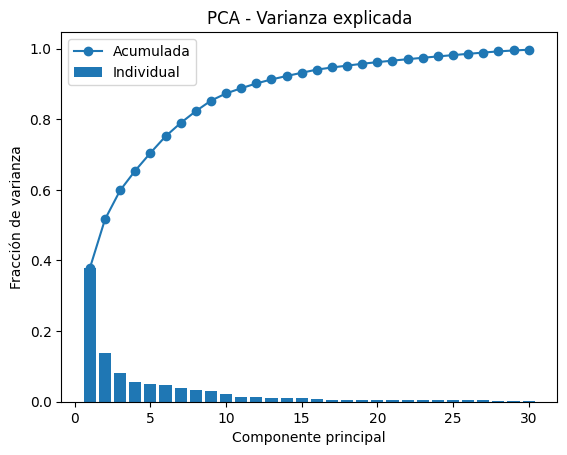

In [53]:
pca = PCA(n_components=30)
pca.fit(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_exp = np.cumsum(exp_var)
k = len(exp_var)

# Varianza explicada
fig, ax = plt.subplots()
ax.bar(range(1, k+1), exp_var, label="Individual")
ax.plot(range(1, k+1), cum_exp, marker="o", label="Acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Fracción de varianza")
ax.set_title("PCA - Varianza explicada")
ax.legend()
plt.show()

In [54]:
pca = PCA(n_components=min(27, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum()
print(f"Dimensión tras PCA: {X_pca.shape}, varianza explicada acumulada: {explained:.3f}")

Dimensión tras PCA: (23230, 27), varianza explicada acumulada: 0.989


In [55]:
# Vamos a ajustar una regresión lineal simple

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
# Probamos el modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 232593.44
R^2 Score: 0.08


In [57]:
# Probaremos hacerlo ahora con los datos SIN PCA, para comparar resultados
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model_full = LinearRegression()
model_full.fit(X_train_full, y_train_full)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
# Probamos el modelo
y_pred_full = model_full.predict(X_test_full)
mse_full = mean_squared_error(y_test_full, y_pred_full)
r2_full = r2_score(y_test_full, y_pred_full)
print(f"Mean Squared Error (sin PCA): {mse_full:.2f}")
print(f"R^2 Score (sin PCA): {r2_full:.2f}")

Mean Squared Error (sin PCA): 233567.98
R^2 Score (sin PCA): 0.07


In [59]:
# Vamos a ver cuales son las variables que pesan en la regresión sin PCA
columnas_importantes = pd.Series(model_full.coef_, index=X_scaled.columns)
columnas_importantes = columnas_importantes.abs().sort_values(ascending=False).head(10)
print("Top 10 variables más importantes en la regresión lineal sin PCA:")
print(columnas_importantes)

Top 10 variables más importantes en la regresión lineal sin PCA:
positive_ratings                      3326.658884
negative_ratings                      1638.907138
achievements                           680.041170
median_playtime_infrequent_sklearn     497.722113
revenue                                458.486820
owners_infrequent_sklearn              222.161005
firstreleasedate                       217.396562
owners_50000-100000                    212.646626
owners_500000-1000000                  204.971623
publisherclass_Hobbyist                163.806748
dtype: float64


In [60]:
# Ahora probaremos con un modelo de regresión polinómica de grado 2

def polynomial_features(X, degree=2):
    from itertools import combinations_with_replacement
    n_samples, n_features = X.shape
    features = [X]
    
    for deg in range(2, degree + 1):
        for items in combinations_with_replacement(range(n_features), deg):
            new_feature = np.prod(X[:, items], axis=1).reshape(-1, 1)
            features.append(new_feature)
    
    return np.hstack(features)

X_poly = polynomial_features(X_scaled.values, degree=2)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [61]:
# Probamos el modelo
y_pred_poly = model_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Mean Squared Error (sin PCA): {mse_poly:.2f}")
print(f"R^2 Score (sin PCA): {r2_poly:.2f}")

Mean Squared Error (sin PCA): 334932.95
R^2 Score (sin PCA): -0.33


In [62]:
"""# Probaremos con grado 3 ahora. 
X_poly = polynomial_features(X_scaled.values, degree=3)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)


# Probamos el modelo
y_pred_poly = model_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Mean Squared Error (sin PCA): {mse_poly:.2f}")
print(f"R^2 Score (sin PCA): {r2_poly:.2f}")"""

'# Probaremos con grado 3 ahora. \nX_poly = polynomial_features(X_scaled.values, degree=3)\nX_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)\nmodel_poly = LinearRegression()\nmodel_poly.fit(X_train_poly, y_train_poly)\n\n\n# Probamos el modelo\ny_pred_poly = model_poly.predict(X_test_poly)\nmse_poly = mean_squared_error(y_test, y_pred_poly)\nr2_poly = r2_score(y_test, y_pred_poly)\nprint(f"Mean Squared Error (sin PCA): {mse_poly:.2f}")\nprint(f"R^2 Score (sin PCA): {r2_poly:.2f}")'

In [63]:
# Definimos el umbral para clasificar
threshold = 100

In [64]:
# Probemos un enfoque distinto, en cambio crearemos una nueva columna con un 'threshold' de playtime y haremos clasificación.
# Es decir, si el playtime es mayor a X horas, clase 1, sino clase 0.
df_filtrado['high_playtime'] = (df_filtrado['average_playtime'] > threshold).astype(int)

# Creamos también una columna que sea la razón entre rating positivos y negativos
df_filtrado['rating_ratio'] = df_filtrado['positive_ratings'] / (df_filtrado['negative_ratings'] + 1)  # +1 para evitar división por cero

X = df_filtrado.drop(columns=["average_playtime", "high_playtime", "median_playtime", "owners", "revenue", "positive_ratings", "negative_ratings", "copiessold"]).copy()
y = df_filtrado["high_playtime"].copy()

columnas_cuantitativas = ["price", "required_age", "achievements", "rating_ratio", "reviewscore"]
columnas_lista = ["platforms", "genres", "categories"]


df_cuantitativo = X[columnas_cuantitativas].copy()
df_lista = X[columnas_lista].copy()
df_cualitativo = X.drop(columns=list(df_cuantitativo.columns) + list(df_lista.columns)).copy()

df_binarizado_total = pd.DataFrame()

for columna in columnas_lista:
    listas = df_lista[columna].fillna('').str.split(';')
    mlb = MultiLabelBinarizer()
    datos_binarizados = mlb.fit_transform(listas)
    df_temp = pd.DataFrame(datos_binarizados,
                           columns=mlb.classes_,
                           index=df_lista.index).add_prefix(f'{columna}_')
    df_binarizado_total = pd.concat([df_binarizado_total, df_temp], axis=1)

generos_binarizados = mlb.fit_transform(df_lista)

encoder = OneHotEncoder(
    min_frequency=100, # Agrupa categorías que aparecen menos de 100 veces
    handle_unknown='ignore',
    dtype=np.float32,
    drop="first"
)

result = encoder.fit_transform(df_cualitativo).toarray()

column_names = encoder.get_feature_names_out(df_cualitativo.columns)

data_scaled = pd.DataFrame(result, columns=column_names, index=df_cualitativo.index)
# df_encoded = pd.concat([data_scaled, df_cuantitativo, df_binarizado_total], axis=1)
df_encoded = pd.concat([data_scaled, df_cuantitativo], axis=1)
df_encoded.head()

scaler = MinMaxScaler()
#Falta OneHotEncoder y lo que hice arriba con el multilabel (mañana lo termino antes de la reu)
X_scaled = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns, index=df_encoded.index)


pca = PCA(n_components=min(27, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum()
print(f"Dimensión tras PCA: {X_pca.shape}, varianza explicada acumulada: {explained:.3f}")

Dimensión tras PCA: (23230, 27), varianza explicada acumulada: 0.959


# SECCION PCA

In [65]:
X_train_PCA, X_test_PCA, y_train_PCA, y_test_PCA = train_test_split(X_pca, y, test_size=0.2, random_state=42)

### Regresión Logística

In [66]:
# Aplicaremos Regresión Logística
logistic = LogisticRegression(random_state=42, max_iter=1000)
logistic.fit(X_train_PCA, y_train_PCA)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
# Testamos el modelo
y_pred_log_PCA = logistic.predict(X_test_PCA)

# Classification report
print(classification_report(y_test_PCA, y_pred_log_PCA))
print(confusion_matrix(y_test_PCA, y_pred_log_PCA))


              precision    recall  f1-score   support

           0       0.86      0.99      0.92      3992
           1       0.57      0.05      0.10       654

    accuracy                           0.86      4646
   macro avg       0.72      0.52      0.51      4646
weighted avg       0.82      0.86      0.81      4646

[[3966   26]
 [ 619   35]]


In [68]:
# Veamos las componentes que más pesan en la regresión logística
coeficientes_log = pd.Series(logistic.coef_[0], index=[f'PC{i+1}' for i in range(X_pca.shape[1])])
coeficientes_log = coeficientes_log.abs().sort_values(ascending=False).head(10)
print("Top 10 componentes principales más importantes en la regresión logística:")
print(coeficientes_log)

Top 10 componentes principales más importantes en la regresión logística:
PC5     1.812856
PC8     1.735328
PC4     1.502886
PC7     1.498607
PC1     1.460390
PC3     1.236590
PC18    1.172156
PC10    1.079788
PC15    0.929552
PC14    0.790472
dtype: float64


## Random Forest

In [69]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    max_features='sqrt',
    oob_score=True,
    random_state=42
)
rf.fit(X_train_PCA, y_train_PCA)
yhat_rf_train = rf.predict(X_train_PCA)
yhat_rf_test = rf.predict(X_test_PCA)

In [70]:
print('Random Forest - Accuracy train:', accuracy_score(y_train_PCA, yhat_rf_train))
print('Random Forest - Accuracy test :', accuracy_score(y_test_PCA, yhat_rf_test))
print('OOB score:', rf.oob_score_)

Random Forest - Accuracy train: 0.9150882479552304
Random Forest - Accuracy test : 0.8562204046491606
OOB score: 0.8561665949203616


In [71]:
print('\nReporte (test):\n', classification_report(y_test_PCA, yhat_rf_test))
print('Matriz de confusión (test):\n', confusion_matrix(y_test_PCA, yhat_rf_test))


Reporte (test):
               precision    recall  f1-score   support

           0       0.87      0.98      0.92      3992
           1       0.46      0.11      0.18       654

    accuracy                           0.86      4646
   macro avg       0.66      0.54      0.55      4646
weighted avg       0.81      0.86      0.82      4646

Matriz de confusión (test):
 [[3906   86]
 [ 582   72]]


In [72]:
# Queremos ver ahora las features más importantes según el Random Forest
nombres = [f'PC{i+1}' for i in range(X_pca.shape[1])]

importancias = pd.Series(rf.feature_importances_, index=nombres)
importancias = importancias.sort_values(ascending=False).head(10)
print("Top 10 componentes principales más importantes según Random Forest:")
print(importancias)

Top 10 componentes principales más importantes según Random Forest:
PC1     0.075135
PC2     0.057846
PC18    0.050702
PC27    0.046931
PC14    0.041316
PC5     0.041161
PC6     0.039821
PC22    0.037734
PC12    0.036549
PC7     0.036139
dtype: float64


### KNN

Mejor K según CV: 1


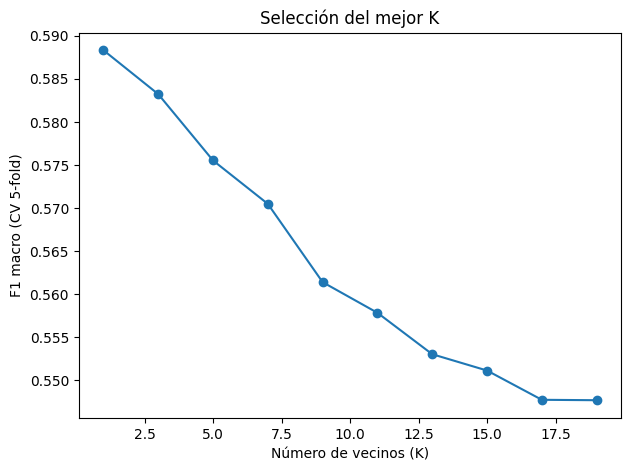

In [73]:
k_values = range(1, 21, 2)
scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train_PCA, y_train_PCA, cv=5, scoring="f1_macro").mean()
    scores.append(cv_score)

best_k = k_values[np.argmax(scores)]
print("Mejor K según CV:", best_k)

plt.figure(figsize=(7,5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("F1 macro (CV 5-fold)")
plt.title("Selección del mejor K")
plt.show()

In [74]:
# Aplicamos KNN con el mejor K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_PCA, y_train_PCA)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [75]:
# Sacamos predicciones
y_pred_knn_PCA = knn.predict(X_test_PCA)

# Classification report
print(classification_report(y_test_PCA, y_pred_knn_PCA))
print(confusion_matrix(y_test_PCA, y_pred_knn_PCA))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3992
           1       0.28      0.29      0.29       654

    accuracy                           0.79      4646
   macro avg       0.58      0.59      0.58      4646
weighted avg       0.80      0.79      0.80      4646

[[3500  492]
 [ 462  192]]


# SECCIÓN SIN PCA

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Regresión Logística

In [77]:
# Haremos lo mismo pero sin PCA
logistic_full = LogisticRegression(random_state=42, max_iter=1000)
logistic_full.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
# Testamos el modelo
y_pred_log = logistic_full.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.86      0.99      0.92      3992
           1       0.59      0.05      0.09       654

    accuracy                           0.86      4646
   macro avg       0.73      0.52      0.51      4646
weighted avg       0.83      0.86      0.81      4646

[[3969   23]
 [ 621   33]]


In [79]:
# Veamos los componentes que más pesan en la regresión logística SIN PCA
coeficientes_log_full = pd.Series(logistic_full.coef_[0], index=X_scaled.columns)
coeficientes_log_full = coeficientes_log_full.abs().sort_values(ascending=False).head(10)
print("Top 10 variables más importantes en la regresión logística sin PCA:")
print(coeficientes_log_full)

Top 10 variables más importantes en la regresión logística sin PCA:
publisherclass_Hobbyist                    2.690911
publisher_infrequent_sklearn               1.768028
rating_ratio                               1.669643
price                                      1.531970
steamspy_tags_Indie                        1.365784
english_t                                  1.363703
steamspy_tags_Early Access;Action;Indie    1.363660
steamspy_tags_Indie;Action;Adventure       1.105279
steamspy_tags_Indie;Casual;Action          1.071417
steamspy_tags_Early Access;Indie;Casual    1.013518
dtype: float64


### Random Forest

In [80]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    max_features='sqrt',
    oob_score=True,
    random_state=42
)
rf.fit(X_train, y_train)
yhat_rf_train = rf.predict(X_train)
yhat_rf_test = rf.predict(X_test)

In [81]:
print('Random Forest - Accuracy train:', accuracy_score(y_train_PCA, yhat_rf_train))
print('Random Forest - Accuracy test :', accuracy_score(y_test_PCA, yhat_rf_test))
print('OOB score:', rf.oob_score_)

Random Forest - Accuracy train: 0.9104606112785192
Random Forest - Accuracy test : 0.8635385277658201
OOB score: 0.8612247094274645


In [82]:
print('\nReporte (test):\n', classification_report(y_test, yhat_rf_test))
print('Matriz de confusión (test):\n', confusion_matrix(y_test, yhat_rf_test))


Reporte (test):
               precision    recall  f1-score   support

           0       0.87      0.99      0.93      3992
           1       0.59      0.10      0.17       654

    accuracy                           0.86      4646
   macro avg       0.73      0.54      0.55      4646
weighted avg       0.83      0.86      0.82      4646

Matriz de confusión (test):
 [[3946   46]
 [ 588   66]]


In [83]:
# Queremos ver ahora las features más importantes según el Random Forest, ahora SIN PCA
nombres = X_scaled.columns
importancias = pd.Series(rf.feature_importances_, index=nombres)
importancias = importancias.sort_values(ascending=False).head(10)
print("Top 10 variables más importantes según Random Forest sin PCA:")
print(importancias)

Top 10 variables más importantes según Random Forest sin PCA:
rating_ratio                        0.247332
reviewscore                         0.175549
achievements                        0.168902
price                               0.161503
publisherclass_Hobbyist             0.086298
publisherclass_Indie                0.035024
publisherclass_AAA                  0.028359
required_age                        0.017995
steamspy_tags_infrequent_sklearn    0.015154
earlyaccess_True                    0.008361
dtype: float64


### KNN

Mejor K según CV: 1


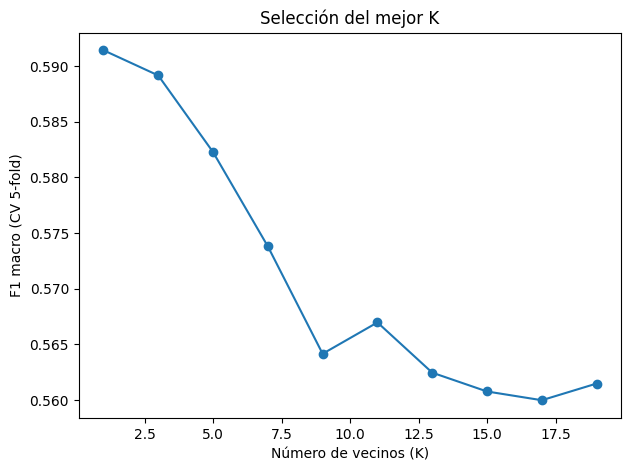

In [84]:
k_values = range(1, 21, 2)
scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring="f1_macro").mean()
    scores.append(cv_score)

best_k = k_values[np.argmax(scores)]
print("Mejor K según CV:", best_k)

plt.figure(figsize=(7,5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("F1 macro (CV 5-fold)")
plt.title("Selección del mejor K")
plt.show()

In [85]:
# Aplicamos KNN con el mejor K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [86]:
# Sacamos predicciones
y_pred_knn = knn.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      3992
           1       0.29      0.31      0.30       654

    accuracy                           0.79      4646
   macro avg       0.59      0.59      0.59      4646
weighted avg       0.80      0.79      0.80      4646

[[3491  501]
 [ 453  201]]
